In [5]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../datasets/ml_training_dataset_v3_cleaned.csv")

X = df[
    [
        'application_type',
        'expected_users_per_day',
        'concurrent_users',
        'storage_required_gb',
        'deployment_region',
        'traffic_pattern'
    ]
]

# One-hot encode
X = pd.get_dummies(X)

# Load trained model
rf_model = joblib.load("../models/cloud_model.pkl")
from sklearn.model_selection import train_test_split

y = df[
    [
        'required_vcpu',
        'required_ram_gb'
    ]
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

rf_predictions = rf_model.predict(X_test)

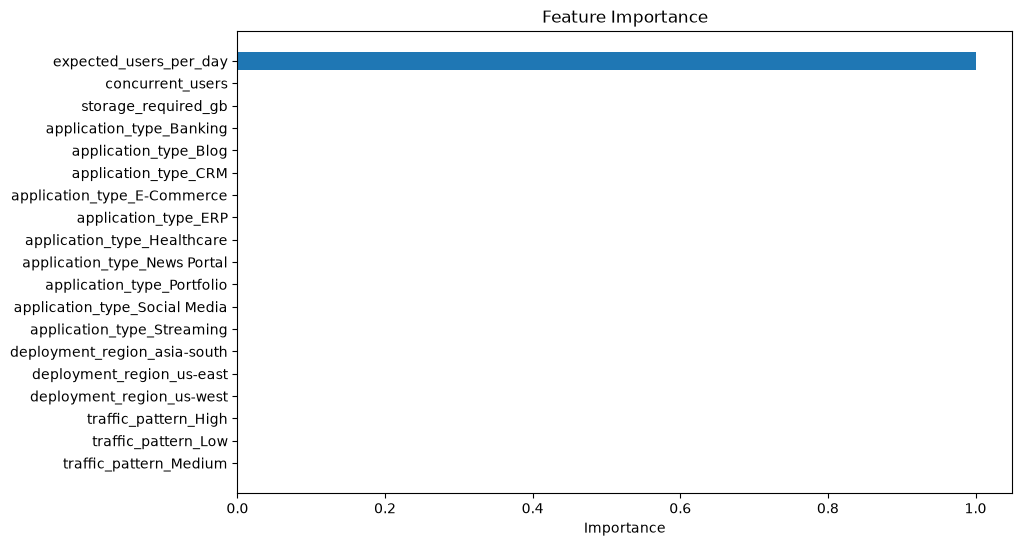

In [6]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [7]:
feature_importance.head(10)

,Feature,Importance
0,expected_users_per_day,1.0
1,concurrent_users,0.0
2,storage_required_gb,0.0
3,application_type_Banking,0.0
4,application_type_Blog,0.0
5,application_type_CRM,0.0
6,application_type_E-Commerce,0.0
7,application_type_ERP,0.0
8,application_type_Healthcare,0.0
9,application_type_News Portal,0.0


In [8]:
df.groupby("required_vcpu")["expected_users_per_day"].describe()

,count,mean,std,min,25%,50%,75%,max
required_vcpu,,,,,,,,
1,1859.0,1187.074771,653.899380,100.0,666.00,1147.0,1662.00,2973.0
2,3124.0,14000.974712,7940.636659,3004.0,7246.75,11515.0,20770.25,29999.0
4,5640.0,63735.200887,19682.959562,30000.0,47236.25,63427.5,79501.00,99969.0
8,2763.0,148462.224756,38033.765917,100000.0,118679.00,138349.0,171347.50,249980.0
16,1614.0,373923.957249,73124.542056,250079.0,309256.75,371487.0,437630.25,499846.0


In [9]:
df.groupby("required_vcpu")["concurrent_users"].describe()

,count,mean,std,min,25%,50%,75%,max
required_vcpu,,,,,,,,
1,1859.0,43.308230,41.926819,5.0,19.0,31.0,45.00,200.0
2,3124.0,1340.643726,1624.477143,20.0,146.0,900.5,2024.75,19777.0
4,5640.0,2591.485993,2829.969658,200.0,1089.0,1894.0,2950.00,19984.0
8,2763.0,5260.924358,5203.361540,201.0,1816.5,3094.0,5893.50,19988.0
16,1614.0,10853.739777,5374.689430,1001.0,6256.0,10813.5,15515.25,19993.0


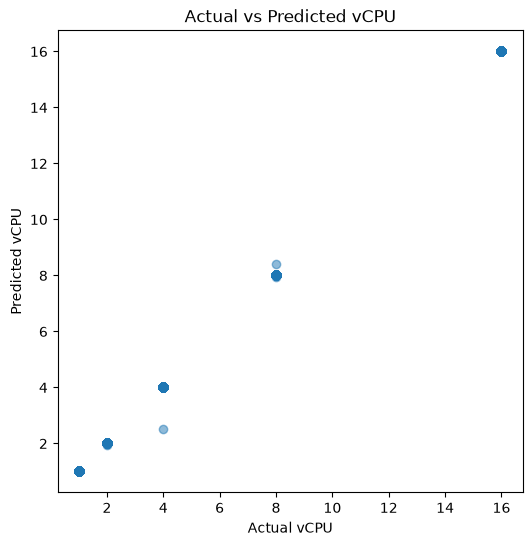

In [10]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test["required_vcpu"],
    rf_predictions[:,0],
    alpha=0.5
)

plt.xlabel("Actual vCPU")
plt.ylabel("Predicted vCPU")
plt.title("Actual vs Predicted vCPU")

plt.show()

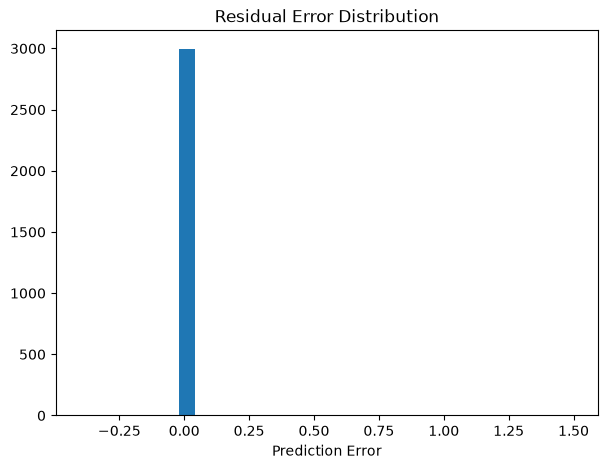

In [11]:
residuals = y_test["required_vcpu"] - rf_predictions[:,0]

plt.figure(figsize=(7,5))

plt.hist(residuals, bins=30)

plt.title("Residual Error Distribution")
plt.xlabel("Prediction Error")

plt.show()

In [12]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[0.84648,0.00067],
    "RMSE":[1.19268,0.02838],
    "R2":[0.9215,0.99995]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,0.84648,1.19268,0.92150
1,Random Forest,0.00067,0.02838,0.99995
